In [142]:
import pandas as pd
import numpy as np

In [145]:
df = pd.read_csv("data/raw/sensor_data.csv")
df.head()

,machine_id,timestamp,temperature,vibration,pressure,rpm
0,M101,2024-01-09 08:00,65.0,0.45,30.0,1500
1,M101,2024-01-09 12:00,70.0,NaN,31.0,1490
2,M101,2024-01-09 16:00,72.0,0.52,30.0,1505
3,M101,2024-01-10 06:00,85.0,0.80,35.0,1450
4,M101,2024-01-10 07:00,120.0,2.50,55.0,1300


In [146]:
df.describe()

,temperature,vibration,pressure,rpm
count,34.000000,33.000000,34.000000,35.000000
mean,75.617647,0.857273,34.147059,1474.285714
std,30.749245,0.681681,9.677003,89.657378
min,-10.000000,0.300000,24.000000,1200.000000
25%,62.250000,0.420000,29.000000,1427.500000
50%,71.000000,0.520000,31.000000,1490.000000
75%,84.750000,1.050000,36.500000,1525.000000
max,200.000000,3.200000,70.000000,1620.000000


In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   machine_id   35 non-null     str    
 1   timestamp    35 non-null     str    
 2   temperature  34 non-null     float64
 3   vibration    33 non-null     float64
 4   pressure     34 non-null     float64
 5   rpm          35 non-null     int64  
dtypes: float64(3), int64(1), str(2)
memory usage: 1.8 KB


In [148]:
df1 = df.drop_duplicates()
df1

,machine_id,timestamp,temperature,vibration,pressure,rpm
0,M101,2024-01-09 08:00,65.0,0.45,30.0,1500
1,M101,2024-01-09 12:00,70.0,NaN,31.0,1490
2,M101,2024-01-09 16:00,72.0,0.52,30.0,1505
3,M101,2024-01-10 06:00,85.0,0.80,35.0,1450
4,M101,2024-01-10 07:00,120.0,2.50,55.0,1300
6,M102,2024-02-04 09:00,60.0,0.40,28.0,1550
7,M102,2024-02-04 13:00,NaN,0.42,29.0,1540
8,M102,2024-02-05 05:00,88.0,1.10,38.0,1420
9,M103,2024-01-21 10:00,55.0,0.35,25.0,1600
10,M103,2024-01-22 08:00,75.0,0.75,33.0,1480


In [149]:
df1.info()

<class 'pandas.DataFrame'>
Index: 34 entries, 0 to 34
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   machine_id   34 non-null     str    
 1   timestamp    34 non-null     str    
 2   temperature  33 non-null     float64
 3   vibration    32 non-null     float64
 4   pressure     33 non-null     float64
 5   rpm          34 non-null     int64  
dtypes: float64(3), int64(1), str(2)
memory usage: 1.9 KB


In [150]:
# Handle missing values
df1[['temperature','vibration','pressure']] = (
    df1.groupby('machine_id')[['temperature', 'vibration','pressure']].ffill()
)
df1

,machine_id,timestamp,temperature,vibration,pressure,rpm
0,M101,2024-01-09 08:00,65.0,0.45,30.0,1500
1,M101,2024-01-09 12:00,70.0,0.45,31.0,1490
2,M101,2024-01-09 16:00,72.0,0.52,30.0,1505
3,M101,2024-01-10 06:00,85.0,0.80,35.0,1450
4,M101,2024-01-10 07:00,120.0,2.50,55.0,1300
6,M102,2024-02-04 09:00,60.0,0.40,28.0,1550
7,M102,2024-02-04 13:00,60.0,0.42,29.0,1540
8,M102,2024-02-05 05:00,88.0,1.10,38.0,1420
9,M103,2024-01-21 10:00,55.0,0.35,25.0,1600
10,M103,2024-01-22 08:00,75.0,0.75,33.0,1480


In [151]:
# remove impossible values
df2 = df1[(df1['temperature']>0) & (df1['temperature'] < 150)]
df2

,machine_id,timestamp,temperature,vibration,pressure,rpm
0,M101,2024-01-09 08:00,65.0,0.45,30.0,1500
1,M101,2024-01-09 12:00,70.0,0.45,31.0,1490
2,M101,2024-01-09 16:00,72.0,0.52,30.0,1505
3,M101,2024-01-10 06:00,85.0,0.80,35.0,1450
4,M101,2024-01-10 07:00,120.0,2.50,55.0,1300
6,M102,2024-02-04 09:00,60.0,0.40,28.0,1550
7,M102,2024-02-04 13:00,60.0,0.42,29.0,1540
8,M102,2024-02-05 05:00,88.0,1.10,38.0,1420
9,M103,2024-01-21 10:00,55.0,0.35,25.0,1600
10,M103,2024-01-22 08:00,75.0,0.75,33.0,1480


In [152]:
df3 = df2[df2['vibration'] < 2.5]
df3

,machine_id,timestamp,temperature,vibration,pressure,rpm
0,M101,2024-01-09 08:00,65.0,0.45,30.0,1500
1,M101,2024-01-09 12:00,70.0,0.45,31.0,1490
2,M101,2024-01-09 16:00,72.0,0.52,30.0,1505
3,M101,2024-01-10 06:00,85.0,0.80,35.0,1450
6,M102,2024-02-04 09:00,60.0,0.40,28.0,1550
7,M102,2024-02-04 13:00,60.0,0.42,29.0,1540
8,M102,2024-02-05 05:00,88.0,1.10,38.0,1420
9,M103,2024-01-21 10:00,55.0,0.35,25.0,1600
10,M103,2024-01-22 08:00,75.0,0.75,33.0,1480
11,M104,2024-02-17 11:00,68.0,0.48,30.0,1520


In [153]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [154]:
# Detect outliers (Z-score)

from scipy import stats
import numpy as np

df3['tempz'] = np.abs(stats.zscore(df3['temperature']))
df3.head(10)

,machine_id,timestamp,temperature,vibration,pressure,rpm,tempz
0,M101,2024-01-09 08:00,65.0,0.45,30.0,1500,0.525323
1,M101,2024-01-09 12:00,70.0,0.45,31.0,1490,0.087554
2,M101,2024-01-09 16:00,72.0,0.52,30.0,1505,0.087554
3,M101,2024-01-10 06:00,85.0,0.80,35.0,1450,1.225754
6,M102,2024-02-04 09:00,60.0,0.40,28.0,1550,0.963092
7,M102,2024-02-04 13:00,60.0,0.42,29.0,1540,0.963092
8,M102,2024-02-05 05:00,88.0,1.10,38.0,1420,1.488416
9,M103,2024-01-21 10:00,55.0,0.35,25.0,1600,1.400862
10,M103,2024-01-22 08:00,75.0,0.75,33.0,1480,0.350215
11,M104,2024-02-17 11:00,68.0,0.48,30.0,1520,0.262662


In [155]:
print(df2.shape)
print(df3.shape)

(32, 6)
(31, 7)


In [156]:
print(df3.shape)
df3

(31, 7)


,machine_id,timestamp,temperature,vibration,pressure,rpm,tempz
0,M101,2024-01-09 08:00,65.0,0.45,30.0,1500,0.525323
1,M101,2024-01-09 12:00,70.0,0.45,31.0,1490,0.087554
2,M101,2024-01-09 16:00,72.0,0.52,30.0,1505,0.087554
3,M101,2024-01-10 06:00,85.0,0.80,35.0,1450,1.225754
6,M102,2024-02-04 09:00,60.0,0.40,28.0,1550,0.963092
7,M102,2024-02-04 13:00,60.0,0.42,29.0,1540,0.963092
8,M102,2024-02-05 05:00,88.0,1.10,38.0,1420,1.488416
9,M103,2024-01-21 10:00,55.0,0.35,25.0,1600,1.400862
10,M103,2024-01-22 08:00,75.0,0.75,33.0,1480,0.350215
11,M104,2024-02-17 11:00,68.0,0.48,30.0,1520,0.262662


In [157]:
df_outliers = df3[df3['tempz']>3]
print(df_outliers.shape)

(0, 7)


In [158]:
print(df3['tempz'].max())

2.0137386678400215


In [159]:
df3.loc[1:6, 'vibration']

1    0.45
2    0.52
3    0.80
6    0.40
Name: vibration, dtype: float64

In [160]:
df3.iloc[2:4, 1:3]

,timestamp,temperature
2,2024-01-09 16:00,72.0
3,2024-01-10 06:00,85.0


In [161]:
df3.iloc[2,0]

'M101'

In [162]:
# Identify Failure Pattern Before Breakdown

df3['temp_rolling_mean'] = df3.groupby('machine_id')['temperature'].rolling(2).mean().reset_index(0,drop=True)

df3['vibration_spike'] = np.where(df3['vibration'] > df3['vibration'].mean() + 2*df3['vibration'].std(), 1, 0)

In [163]:
df3.head(31)

# threshold = mean + 2 * std

,machine_id,timestamp,temperature,vibration,pressure,rpm,tempz,temp_rolling_mean,vibration_spike
0,M101,2024-01-09 08:00,65.0,0.45,30.0,1500,0.525323,NaN,0
1,M101,2024-01-09 12:00,70.0,0.45,31.0,1490,0.087554,67.5,0
2,M101,2024-01-09 16:00,72.0,0.52,30.0,1505,0.087554,71.0,0
3,M101,2024-01-10 06:00,85.0,0.80,35.0,1450,1.225754,78.5,0
6,M102,2024-02-04 09:00,60.0,0.40,28.0,1550,0.963092,NaN,0
7,M102,2024-02-04 13:00,60.0,0.42,29.0,1540,0.963092,60.0,0
8,M102,2024-02-05 05:00,88.0,1.10,38.0,1420,1.488416,74.0,0
9,M103,2024-01-21 10:00,55.0,0.35,25.0,1600,1.400862,NaN,0
10,M103,2024-01-22 08:00,75.0,0.75,33.0,1480,0.350215,65.0,0
11,M104,2024-02-17 11:00,68.0,0.48,30.0,1520,0.262662,NaN,0


In [164]:
avg = df3['vibration'].mean()
avg

np.float64(0.6393548387096775)

In [165]:
std = df3['vibration'].std()
std

np.float64(0.30806855821251833)

In [166]:
avg+ 2*std

np.float64(1.2554919551347141)

In [171]:
# Always create copy when slicing
df3 = df3[df3['temperature'] > 0].copy()

# Convert timestamp safely # timeseries concept
df3['timestamp'] = pd.to_datetime(df3['timestamp'])

# Load maintenance logs
maintenance = pd.read_csv("data/raw/maintenance_logs.csv")

# Convert failure date
maintenance['failure_date'] = pd.to_datetime(maintenance['failure_date'])

# Merge
merged = pd.merge(df3, maintenance, on='machine_id', how='left')



In [172]:
maintenance

,machine_id,failure_date,failure_type,repair_time_hours,technician
0,M101,2024-01-10,Motor,6,Tech_A
1,M101,2024-03-14,Bearing,4,Tech_B
2,M102,2024-02-05,Hydraulic,9,Tech_C
3,M103,2024-01-22,Sensor,3,Tech_A
4,M104,2024-02-18,Electrical,7,Tech_D
5,M105,2024-03-10,Motor,5,Tech_A
6,M106,2024-01-30,Hydraulic,8,Tech_C
7,M107,2024-02-12,Bearing,4,Tech_B
8,M108,2024-03-01,Sensor,2,Tech_A
9,M109,2024-01-15,Electrical,6,Tech_D


In [173]:
merged

,machine_id,timestamp,temperature,vibration,pressure,rpm,tempz,temp_rolling_mean,vibration_spike,failure_date,failure_type,repair_time_hours,technician
0,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-01-10,Motor,6,Tech_A
1,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-03-14,Bearing,4,Tech_B
2,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-05-10,Motor,7,Tech_A
3,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-01-10,Motor,6,Tech_A
4,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-03-14,Bearing,4,Tech_B
5,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-05-10,Motor,7,Tech_A
6,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-01-10,Motor,6,Tech_A
7,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-03-14,Bearing,4,Tech_B
8,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-05-10,Motor,7,Tech_A
9,M101,2024-01-10 06:00:00,85.0,0.80,35.0,1450,1.225754,78.5,0,2024-01-10,Motor,6,Tech_A


In [174]:
print(merged.dtypes)

machine_id                      str
timestamp            datetime64[us]
temperature                 float64
vibration                   float64
pressure                    float64
rpm                           int64
tempz                       float64
temp_rolling_mean           float64
vibration_spike               int64
failure_date         datetime64[us]
failure_type                    str
repair_time_hours             int64
technician                      str
dtype: object


In [175]:
merged['timestamp'] = pd.to_datetime(merged['timestamp'], errors='coerce')

In [176]:
print(merged.dtypes)

machine_id                      str
timestamp            datetime64[us]
temperature                 float64
vibration                   float64
pressure                    float64
rpm                           int64
tempz                       float64
temp_rolling_mean           float64
vibration_spike               int64
failure_date         datetime64[us]
failure_type                    str
repair_time_hours             int64
technician                      str
dtype: object


In [177]:
# Calculate hours before failure
merged['hours_before_failure'] = (
    merged['failure_date'] - merged['timestamp']
).dt.total_seconds() / 3600

In [178]:
merged

,machine_id,timestamp,temperature,vibration,pressure,rpm,tempz,temp_rolling_mean,vibration_spike,failure_date,failure_type,repair_time_hours,technician,hours_before_failure
0,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-01-10,Motor,6,Tech_A,16.0
1,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-03-14,Bearing,4,Tech_B,1552.0
2,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-05-10,Motor,7,Tech_A,2920.0
3,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-01-10,Motor,6,Tech_A,12.0
4,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-03-14,Bearing,4,Tech_B,1548.0
5,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-05-10,Motor,7,Tech_A,2916.0
6,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-01-10,Motor,6,Tech_A,8.0
7,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-03-14,Bearing,4,Tech_B,1544.0
8,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-05-10,Motor,7,Tech_A,2912.0
9,M101,2024-01-10 06:00:00,85.0,0.80,35.0,1450,1.225754,78.5,0,2024-01-10,Motor,6,Tech_A,-6.0


In [179]:
risk_data = merged[
    (merged['hours_before_failure'] <= 24) &
    (merged['hours_before_failure'] >= 0)
]

In [180]:
risk_data

,machine_id,timestamp,temperature,vibration,pressure,rpm,tempz,temp_rolling_mean,vibration_spike,failure_date,failure_type,repair_time_hours,technician,hours_before_failure
0,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-01-10,Motor,6,Tech_A,16.0
3,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-01-10,Motor,6,Tech_A,12.0
6,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-01-10,Motor,6,Tech_A,8.0
12,M102,2024-02-04 09:00:00,60.0,0.40,28.0,1550,0.963092,NaN,0,2024-02-05,Hydraulic,9,Tech_C,15.0
14,M102,2024-02-04 13:00:00,60.0,0.42,29.0,1540,0.963092,60.0,0,2024-02-05,Hydraulic,9,Tech_C,11.0
18,M103,2024-01-21 10:00:00,55.0,0.35,25.0,1600,1.400862,NaN,0,2024-01-22,Sensor,3,Tech_A,14.0
20,M104,2024-02-17 11:00:00,68.0,0.48,30.0,1520,0.262662,NaN,0,2024-02-18,Electrical,7,Tech_D,13.0
22,M105,2024-03-09 08:00:00,63.0,0.42,29.0,1510,0.700431,NaN,0,2024-03-10,Motor,5,Tech_A,16.0
24,M106,2024-01-29 09:00:00,67.0,0.50,30.0,1505,0.350215,NaN,0,2024-01-30,Hydraulic,8,Tech_C,15.0
28,M107,2024-02-11 10:00:00,58.0,0.38,27.0,1580,1.138200,NaN,0,2024-02-12,Bearing,4,Tech_B,14.0


In [183]:
machine_master = pd.read_csv("data/raw/machine_master.csv")
production = pd.read_csv("data/raw/production_logs.csv")
machine_master
production

,machine_id,date,units_produced,defects,shift
0,M101,2024-01-11,1200,15,A
1,M101,2024-01-12,1180,18,B
2,M102,2024-02-06,1500,25,A
3,M103,2024-01-23,980,10,C
4,M104,2024-02-19,1100,20,B
5,M105,2024-03-11,1300,14,A
6,M106,2024-01-31,1400,30,C
7,M107,2024-02-13,1000,12,A
8,M108,2024-03-02,900,8,B
9,M109,2024-01-16,1250,22,C


In [184]:
print(production.columns)

Index(['machine_id', 'date', 'units_produced', 'defects', 'shift'], dtype='str')


In [185]:
production.rename(columns={'date': 'timestamp'}, inplace=True)

In [186]:
print(production.columns)

Index(['machine_id', 'timestamp', 'units_produced', 'defects', 'shift'], dtype='str')


In [187]:
# Convert timestamp in production
production['timestamp'] = pd.to_datetime(production['timestamp'], errors='coerce')

In [188]:
print(production.dtypes)

machine_id                   str
timestamp         datetime64[us]
units_produced             int64
defects                    int64
shift                        str
dtype: object


In [189]:
full_data = merged.merge(machine_master, on='machine_id', how='left')

In [190]:
print(full_data.columns)

Index(['machine_id', 'timestamp', 'temperature', 'vibration', 'pressure',
       'rpm', 'tempz', 'temp_rolling_mean', 'vibration_spike', 'failure_date',
       'failure_type', 'repair_time_hours', 'technician',
       'hours_before_failure', 'plant', 'machine_type', 'install_year'],
      dtype='str')


In [191]:
full_data = full_data.merge(
    production,
    on=['machine_id', 'timestamp'],
    how='left'
)

In [192]:
print(full_data.columns)

Index(['machine_id', 'timestamp', 'temperature', 'vibration', 'pressure',
       'rpm', 'tempz', 'temp_rolling_mean', 'vibration_spike', 'failure_date',
       'failure_type', 'repair_time_hours', 'technician',
       'hours_before_failure', 'plant', 'machine_type', 'install_year',
       'units_produced', 'defects', 'shift'],
      dtype='str')


In [193]:
# Machine Age:
full_data['install_year'] = pd.to_numeric(full_data['install_year'], errors='coerce')

full_data['year'] = pd.to_datetime(full_data['timestamp']).dt.year

full_data['machine_age_years'] = (
    full_data['year'] - full_data['install_year']
)

In [194]:
# Good Units
full_data['good_units'] = (
    full_data['units_produced'] - full_data['defects']
)

In [195]:
full_data.head()

,machine_id,timestamp,temperature,vibration,pressure,rpm,tempz,temp_rolling_mean,vibration_spike,failure_date,...,hours_before_failure,plant,machine_type,install_year,units_produced,defects,shift,year,machine_age_years,good_units
0,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-01-10,...,16.0,Plant_A,CNC,2016,NaN,NaN,NaN,2024,8,NaN
1,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-03-14,...,1552.0,Plant_A,CNC,2016,NaN,NaN,NaN,2024,8,NaN
2,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-05-10,...,2920.0,Plant_A,CNC,2016,NaN,NaN,NaN,2024,8,NaN
3,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-01-10,...,12.0,Plant_A,CNC,2016,NaN,NaN,NaN,2024,8,NaN
4,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-03-14,...,1548.0,Plant_A,CNC,2016,NaN,NaN,NaN,2024,8,NaN


In [196]:
print(machine_master.columns)

Index(['machine_id', 'plant', 'machine_type', 'install_year'], dtype='str')


In [197]:
print(full_data.columns)

Index(['machine_id', 'timestamp', 'temperature', 'vibration', 'pressure',
       'rpm', 'tempz', 'temp_rolling_mean', 'vibration_spike', 'failure_date',
       'failure_type', 'repair_time_hours', 'technician',
       'hours_before_failure', 'plant', 'machine_type', 'install_year',
       'units_produced', 'defects', 'shift', 'year', 'machine_age_years',
       'good_units'],
      dtype='str')


In [198]:
# Defect Rate %
full_data['defect_rate'] = (
    full_data['defects'] / full_data['units_produced']
) * 100

In [199]:
# Availability (Using Repair Time)

full_data['availability'] = 1 - (
    full_data['repair_time_hours'] / 24
)

In [200]:
# Create quality_score

import numpy as np

full_data['quality_score'] = (
    full_data['good_units'] /
    full_data['units_produced'].replace(0, np.nan)
) * 100

In [201]:
print(full_data[['quality_score']].head())

   quality_score
0            NaN
1            NaN
2            NaN
3            NaN
4            NaN


In [202]:
full_data

,machine_id,timestamp,temperature,vibration,pressure,rpm,tempz,temp_rolling_mean,vibration_spike,failure_date,...,install_year,units_produced,defects,shift,year,machine_age_years,good_units,defect_rate,availability,quality_score
0,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-01-10,...,2016,NaN,NaN,NaN,2024,8,NaN,NaN,0.750000,NaN
1,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-03-14,...,2016,NaN,NaN,NaN,2024,8,NaN,NaN,0.833333,NaN
2,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-05-10,...,2016,NaN,NaN,NaN,2024,8,NaN,NaN,0.708333,NaN
3,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-01-10,...,2016,NaN,NaN,NaN,2024,8,NaN,NaN,0.750000,NaN
4,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-03-14,...,2016,NaN,NaN,NaN,2024,8,NaN,NaN,0.833333,NaN
5,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-05-10,...,2016,NaN,NaN,NaN,2024,8,NaN,NaN,0.708333,NaN
6,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-01-10,...,2016,NaN,NaN,NaN,2024,8,NaN,NaN,0.750000,NaN
7,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-03-14,...,2016,NaN,NaN,NaN,2024,8,NaN,NaN,0.833333,NaN
8,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-05-10,...,2016,NaN,NaN,NaN,2024,8,NaN,NaN,0.708333,NaN
9,M101,2024-01-10 06:00:00,85.0,0.80,35.0,1450,1.225754,78.5,0,2024-01-10,...,2016,NaN,NaN,NaN,2024,8,NaN,NaN,0.750000,NaN


In [203]:
# Create OEE = Overall Equipment Effectiveness: How efficiently a machine is being used
# OEE = Availability × Performance × Quality
# Your performance = 1 (for now)

full_data['performance'] = 1

full_data['OEE'] = (
    full_data['availability'] *
    full_data['performance'] *
    (full_data['quality_score'] / 100)
) * 100

In [204]:
print(full_data.columns)

Index(['machine_id', 'timestamp', 'temperature', 'vibration', 'pressure',
       'rpm', 'tempz', 'temp_rolling_mean', 'vibration_spike', 'failure_date',
       'failure_type', 'repair_time_hours', 'technician',
       'hours_before_failure', 'plant', 'machine_type', 'install_year',
       'units_produced', 'defects', 'shift', 'year', 'machine_age_years',
       'good_units', 'defect_rate', 'availability', 'quality_score',
       'performance', 'OEE'],
      dtype='str')


In [205]:
full_data

,machine_id,timestamp,temperature,vibration,pressure,rpm,tempz,temp_rolling_mean,vibration_spike,failure_date,...,defects,shift,year,machine_age_years,good_units,defect_rate,availability,quality_score,performance,OEE
0,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-01-10,...,NaN,NaN,2024,8,NaN,NaN,0.750000,NaN,1,NaN
1,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-03-14,...,NaN,NaN,2024,8,NaN,NaN,0.833333,NaN,1,NaN
2,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,NaN,0,2024-05-10,...,NaN,NaN,2024,8,NaN,NaN,0.708333,NaN,1,NaN
3,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-01-10,...,NaN,NaN,2024,8,NaN,NaN,0.750000,NaN,1,NaN
4,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-03-14,...,NaN,NaN,2024,8,NaN,NaN,0.833333,NaN,1,NaN
5,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-05-10,...,NaN,NaN,2024,8,NaN,NaN,0.708333,NaN,1,NaN
6,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-01-10,...,NaN,NaN,2024,8,NaN,NaN,0.750000,NaN,1,NaN
7,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-03-14,...,NaN,NaN,2024,8,NaN,NaN,0.833333,NaN,1,NaN
8,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-05-10,...,NaN,NaN,2024,8,NaN,NaN,0.708333,NaN,1,NaN
9,M101,2024-01-10 06:00:00,85.0,0.80,35.0,1450,1.225754,78.5,0,2024-01-10,...,NaN,NaN,2024,8,NaN,NaN,0.750000,NaN,1,NaN


In [206]:
print(full_data.columns)


Index(['machine_id', 'timestamp', 'temperature', 'vibration', 'pressure',
       'rpm', 'tempz', 'temp_rolling_mean', 'vibration_spike', 'failure_date',
       'failure_type', 'repair_time_hours', 'technician',
       'hours_before_failure', 'plant', 'machine_type', 'install_year',
       'units_produced', 'defects', 'shift', 'year', 'machine_age_years',
       'good_units', 'defect_rate', 'availability', 'quality_score',
       'performance', 'OEE'],
      dtype='str')


In [208]:
full_data.to_csv("data/processed/final_manufacturing_analytics.csv", index=False)

In [209]:
full_data.isna().sum()

machine_id               0
timestamp                0
temperature              0
vibration                0
pressure                 0
rpm                      0
tempz                    0
temp_rolling_mean       25
vibration_spike          0
failure_date             0
failure_type             0
repair_time_hours        0
technician               0
hours_before_failure     0
plant                    0
machine_type             0
install_year             0
units_produced          54
defects                 54
shift                   54
year                     0
machine_age_years        0
good_units              54
defect_rate             54
availability             0
quality_score           54
performance              0
OEE                     54
dtype: int64

In [210]:
import numpy as np

production_cols = [
    'units_produced',
    'defects',
    'good_units',
    'defect_rate',
    'quality_score',
    'OEE'
]

full_data[production_cols] = full_data[production_cols].fillna(0)

full_data['shift'] = full_data['shift'].fillna('No Production')

In [211]:
full_data['temp_rolling_mean'] = full_data['temp_rolling_mean'].fillna(
    full_data['temperature']
)

In [212]:
full_data.isna().sum()

machine_id              0
timestamp               0
temperature             0
vibration               0
pressure                0
rpm                     0
tempz                   0
temp_rolling_mean       0
vibration_spike         0
failure_date            0
failure_type            0
repair_time_hours       0
technician              0
hours_before_failure    0
plant                   0
machine_type            0
install_year            0
units_produced          0
defects                 0
shift                   0
year                    0
machine_age_years       0
good_units              0
defect_rate             0
availability            0
quality_score           0
performance             0
OEE                     0
dtype: int64

In [213]:
full_data.to_csv("data/processed/final_manufacturing_analytics_handled_NaN.csv", index=False)

In [214]:
full_data

,machine_id,timestamp,temperature,vibration,pressure,rpm,tempz,temp_rolling_mean,vibration_spike,failure_date,...,defects,shift,year,machine_age_years,good_units,defect_rate,availability,quality_score,performance,OEE
0,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,65.0,0,2024-01-10,...,0.0,No Production,2024,8,0.0,0.0,0.750000,0.0,1,0.0
1,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,65.0,0,2024-03-14,...,0.0,No Production,2024,8,0.0,0.0,0.833333,0.0,1,0.0
2,M101,2024-01-09 08:00:00,65.0,0.45,30.0,1500,0.525323,65.0,0,2024-05-10,...,0.0,No Production,2024,8,0.0,0.0,0.708333,0.0,1,0.0
3,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-01-10,...,0.0,No Production,2024,8,0.0,0.0,0.750000,0.0,1,0.0
4,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-03-14,...,0.0,No Production,2024,8,0.0,0.0,0.833333,0.0,1,0.0
5,M101,2024-01-09 12:00:00,70.0,0.45,31.0,1490,0.087554,67.5,0,2024-05-10,...,0.0,No Production,2024,8,0.0,0.0,0.708333,0.0,1,0.0
6,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-01-10,...,0.0,No Production,2024,8,0.0,0.0,0.750000,0.0,1,0.0
7,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-03-14,...,0.0,No Production,2024,8,0.0,0.0,0.833333,0.0,1,0.0
8,M101,2024-01-09 16:00:00,72.0,0.52,30.0,1505,0.087554,71.0,0,2024-05-10,...,0.0,No Production,2024,8,0.0,0.0,0.708333,0.0,1,0.0
9,M101,2024-01-10 06:00:00,85.0,0.80,35.0,1450,1.225754,78.5,0,2024-01-10,...,0.0,No Production,2024,8,0.0,0.0,0.750000,0.0,1,0.0


In [216]:
%pip install seaborn matplotlib

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ---------------------- --------------- 30.7/52.8 kB 330.3 kB/s eta 0:00:01
     ------------------------------------ - 51.2/52.8 kB 435.7 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 340.7 kB/s eta 0:00:00
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     ------------- ------------------------- 41.0/119.8 kB 1.9 MB/s eta 0:00:01
     -------------------------------------- 119.8/119.8 kB 1.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   --------- ------------------------------ 71.7/294.9 kB 1.3 MB/s eta 0:00:01
   ---------------- ----------------------- 122.9/294.9 kB 1.4 MB/s eta 0:00:01
   ----------------------- ---------------- 174.1/294.9 kB 1.5 MB/s eta 0:00:01
   ---------------------------------- ----- 256.0/294.9 kB 1.3 MB/s eta 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [219]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='timestamp', ylabel='OEE'>

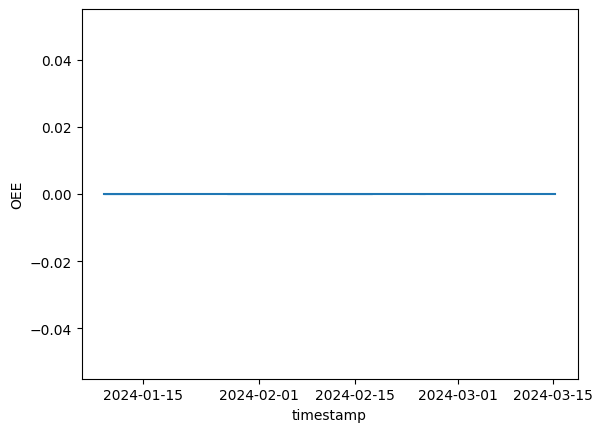

In [220]:
sns.lineplot(data=full_data, x="timestamp", y="OEE")

In [221]:
full_data.select_dtypes(exclude = 'number')

,machine_id,timestamp,failure_date,failure_type,technician,plant,machine_type,shift
0,M101,2024-01-09 08:00:00,2024-01-10,Motor,Tech_A,Plant_A,CNC,No Production
1,M101,2024-01-09 08:00:00,2024-03-14,Bearing,Tech_B,Plant_A,CNC,No Production
2,M101,2024-01-09 08:00:00,2024-05-10,Motor,Tech_A,Plant_A,CNC,No Production
3,M101,2024-01-09 12:00:00,2024-01-10,Motor,Tech_A,Plant_A,CNC,No Production
4,M101,2024-01-09 12:00:00,2024-03-14,Bearing,Tech_B,Plant_A,CNC,No Production
5,M101,2024-01-09 12:00:00,2024-05-10,Motor,Tech_A,Plant_A,CNC,No Production
6,M101,2024-01-09 16:00:00,2024-01-10,Motor,Tech_A,Plant_A,CNC,No Production
7,M101,2024-01-09 16:00:00,2024-03-14,Bearing,Tech_B,Plant_A,CNC,No Production
8,M101,2024-01-09 16:00:00,2024-05-10,Motor,Tech_A,Plant_A,CNC,No Production
9,M101,2024-01-10 06:00:00,2024-01-10,Motor,Tech_A,Plant_A,CNC,No Production


<Axes: >

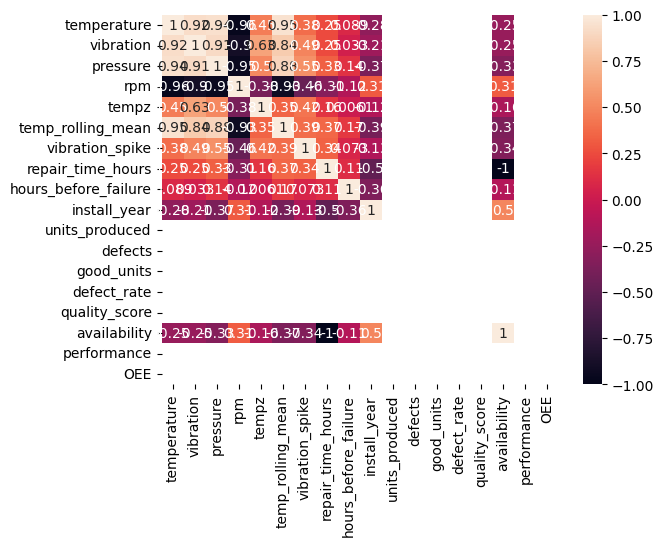

In [105]:
sns.heatmap(full_data.select_dtypes(include='number').corr(), annot=True)